[Font] 未找到中文字体，中文可能显示为方框
检测到 Google Drive，结果将保存至: /content/drive/MyDrive/实验17_1_Noise2Noise与自监督去噪
使用设备: cuda
加载MNIST数据集...

Step 1: 四种学习设定的数据构造与对比
  已保存: step1_four_settings.png
  说明: 设定1-3需要干净数据x，设定4仅需要噪声观测y——本章的核心挑战

Step 2: Noise2Noise原理验证

  训练监督基线 (Supervised)...
  [Supervised] Epoch 10/30, Loss: 0.002507
  [Supervised] Epoch 20/30, Loss: 0.002400
  [Supervised] Epoch 30/30, Loss: 0.002346
  监督基线 PSNR = 26.54 dB

  训练Noise2Noise...
  [N2N] Epoch 10/30, Loss: 0.092582
  [N2N] Epoch 20/30, Loss: 0.092463
  [N2N] Epoch 30/30, Loss: 0.092368
  Noise2Noise PSNR = 26.52 dB
  已保存: step2_n2n_vs_supervised.png
  结论: N2N PSNR (26.5dB) ≈ 监督PSNR (26.5dB)
  验证了定理: argmin E‖y'-f(y)‖² = argmin E‖x-f(y)‖² = E[x|y]

Step 3: 朴素自监督损失偏差分析

  训练朴素自监督 (Naive: ‖y-f(y)‖²)...
  [Naive] Epoch 10/30, Loss: 0.000081
  [Naive] Epoch 20/30, Loss: 0.000046
  [Naive] Epoch 30/30, Loss: 0.000021
  朴素自监督 PSNR = 13.25 dB

  朴素自监督散度 div f(y) ≈ 16477.12
  监督模型散度 div f(y) ≈ 419.50
  偏差 = 2σ²·div f ≈ 2965.8809
  这解释了为什

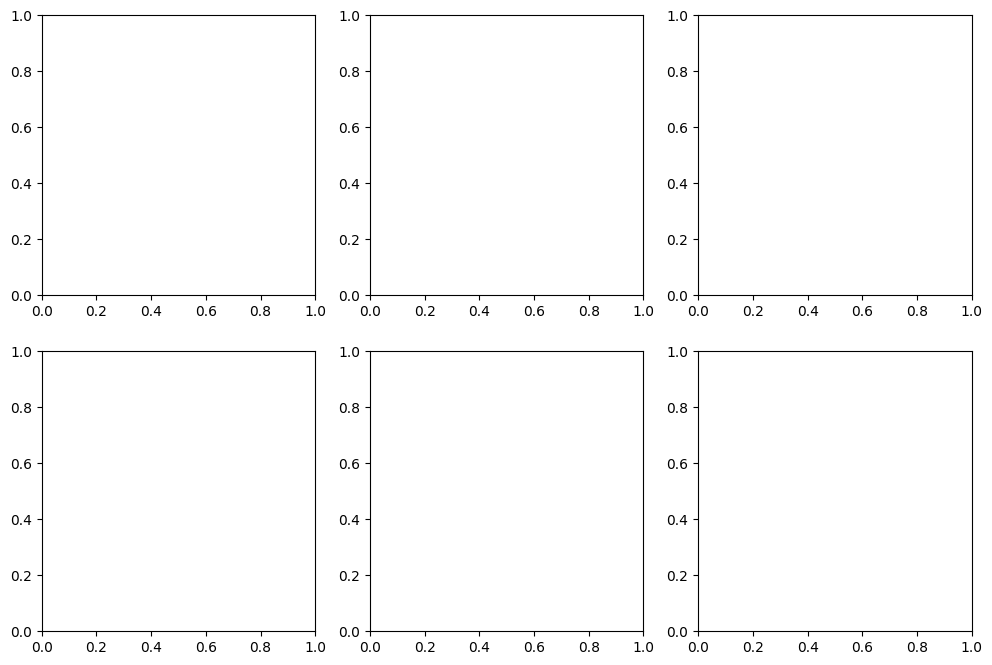

In [ ]:
# -*- coding: utf-8 -*-
"""
实验17.1 Noise2Noise与自监督去噪
对应知识点：17.1节（数据困境与学习设定谱系）、17.2节（Noise2Noise原理）

实验内容：
Step 1: 四种学习设定的数据构造与对比 —— 在MNIST上构造四种设定的数据
Step 2: Noise2Noise原理验证 —— 用配对噪声数据训练，对比监督基线
Step 3: Noise2Noise与朴素自监督损失对比 —— 展示‖y-f(y)‖²的偏差
Step 4: Neighbor2Neighbor空间配对 —— 利用邻域结构近似配对

★原创设计：
- 在MNIST上系统对比四种学习设定的训练效果
- 用散度分析可视化朴素MSE的偏差来源
- Neighbor2Neighbor从单帧噪声图像构造伪配对

素材来源：MiniProject_Self_Supervised中N2N思路、deepinv.loss API
运行前提：需GPU（Colab T4即可）
"""

import os, sys, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux / Colab"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN', 'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os as _os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (_os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

_gdrive = '/content/drive/MyDrive'
if os.path.isdir(_gdrive):
    SAVE_DIR = os.path.join(_gdrive, '实验17_1_Noise2Noise与自监督去噪')
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"检测到 Google Drive，结果将保存至: {SAVE_DIR}")
else:
    SAVE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    print(f"本地环境，结果将保存至: {SAVE_DIR}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


# ========================================================================
# 轻量级UNet（复用自15.2/16.3的SmallUNet架构）
# ========================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class SmallUNet(nn.Module):
    """轻量UNet，用于MNIST 28×28→上采样到32×32"""
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec3 = DoubleConv(base*4, base*2)
        self.dec2 = DoubleConv(base*2, base)
        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)        # (B, base, H, W)
        e2 = self.enc2(self.pool(e1))  # (B, base*2, H/2, W/2)
        e3 = self.enc3(self.pool(e2))  # (B, base*4, H/4, W/4)
        d3 = self.up3(e3)             # (B, base*2, H/2, W/2)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d2 = self.up2(d3)             # (B, base, H, W)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))
        return self.out_conv(d2)


# ========================================================================
# 数据准备：MNIST + 高斯噪声
# ========================================================================
IMG_SIZE = 32  # 上采样到32×32以便UNet下采样
SIGMA = 0.3    # 噪声标准差
BATCH_SIZE = 128
N_EPOCHS = 30
LR = 1e-3

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),  # [0,1]
])

print("加载MNIST数据集...")
mnist_train = datasets.MNIST(root=os.path.join(SAVE_DIR, 'mnist_data'),
                              train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=os.path.join(SAVE_DIR, 'mnist_data'),
                             train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def add_noise(x, sigma=SIGMA):
    """给干净图像添加高斯噪声"""
    return x + sigma * torch.randn_like(x)


# ========================================================================
# Step 1: 四种学习设定的数据构造与对比
# 对应17.1.2节：监督 / 合成配对 / 无监督-x / 无监督-y
# ========================================================================
print("\n" + "="*70)
print("Step 1: 四种学习设定的数据构造与对比")
print("="*70)

# 取一批测试图像做可视化
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs[:8].to(device)
test_noisy = add_noise(test_imgs, SIGMA)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
titles = ['设定1: 监督 (x,y)', '设定2: 合成配对 (x+合成噪声)',
          '设定3: 无监督-x (仅x)', '设定4: 无监督-y (仅y)']
for i in range(8):
    # 设定1: 配对 (x, y)
    axes[0, i].imshow(test_imgs[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    # 设定2: 合成配对 (从x合成y)
    axes[1, i].imshow(test_noisy[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    # 设定3: 仅干净图像
    axes[2, i].imshow(test_imgs[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[2, i].axis('off')
    # 设定4: 仅噪声观测
    axes[3, i].imshow(test_noisy[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[3, i].axis('off')

for r in range(4):
    axes[r, 0].set_ylabel(titles[r], fontsize=9, rotation=0, labelpad=100)

fig.suptitle('Step 1: 四种学习设定的数据对比 (σ=%.1f)' % SIGMA, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step1_four_settings.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  已保存: step1_four_settings.png")
print("  说明: 设定1-3需要干净数据x，设定4仅需要噪声观测y——本章的核心挑战")


# ========================================================================
# Step 2: Noise2Noise原理验证
# 对应17.2.1-17.2.2节：配对噪声数据训练，验证N2N等价性
# ========================================================================
print("\n" + "="*70)
print("Step 2: Noise2Noise原理验证")
print("="*70)

def train_model(model, loss_fn, train_loader, n_epochs=N_EPOCHS, tag=""):
    """通用训练循环"""
    optimizer = optim.Adam(model.parameters(), lr=LR)
    model.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0
        n_batch = 0
        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)
            # 构造噪声观测 y = x + ε
            y1 = add_noise(batch_x, SIGMA)
            optimizer.zero_grad()
            pred = model(y1)
            loss = loss_fn(pred, batch_x, y1)  # loss_fn决定用x还是y'作为target
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batch += 1
        avg_loss = epoch_loss / n_batch
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  [{tag}] Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")
    return losses

def evaluate_psnr(model, test_loader, sigma=SIGMA):
    """在测试集上评估PSNR"""
    model.eval()
    psnr_vals = []
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            y = add_noise(batch_x, sigma)
            pred = model(y)
            pred_np = pred.cpu().numpy().clip(0, 1)
            x_np = batch_x.cpu().numpy()
            for i in range(pred_np.shape[0]):
                psnr_vals.append(psnr(x_np[i, 0], pred_np[i, 0], data_range=1.0))
    return np.mean(psnr_vals)

# --- 2a. 监督基线：loss = ‖x - f(y)‖² ---
print("\n  训练监督基线 (Supervised)...")
model_sup = SmallUNet().to(device)
losses_sup = train_model(
    model_sup,
    loss_fn=lambda pred, x, y: nn.MSELoss()(pred, x),  # 用干净x作target
    train_loader=train_loader,
    tag="Supervised"
)
psnr_sup = evaluate_psnr(model_sup, test_loader)
print(f"  监督基线 PSNR = {psnr_sup:.2f} dB")

# --- 2b. Noise2Noise：loss = ‖y' - f(y)‖² ---
print("\n  训练Noise2Noise...")
model_n2n = SmallUNet().to(device)
losses_n2n = train_model(
    model_n2n,
    loss_fn=lambda pred, x, y: nn.MSELoss()(pred, add_noise(x, SIGMA)),  # ★用y'作target
    train_loader=train_loader,
    tag="N2N"
)
psnr_n2n = evaluate_psnr(model_n2n, test_loader)
print(f"  Noise2Noise PSNR = {psnr_n2n:.2f} dB")

# 可视化对比
fig, axes = plt.subplots(3, 6, figsize=(15, 7))
vis_imgs, _ = next(iter(test_loader))
vis_imgs = vis_imgs[:6].to(device)
vis_noisy = add_noise(vis_imgs, SIGMA)

with torch.no_grad():
    pred_sup = model_sup(vis_noisy).cpu().clip(0, 1)
    pred_n2n = model_n2n(vis_noisy).cpu().clip(0, 1)

for i in range(6):
    axes[0, i].imshow(vis_noisy[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'噪声输入', fontsize=9)
    axes[1, i].imshow(pred_sup[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    p_s = psnr(vis_imgs[i,0].cpu().numpy(), pred_sup[i,0].numpy(), data_range=1.0)
    axes[1, i].set_title(f'监督 {p_s:.1f}dB', fontsize=9)
    axes[2, i].imshow(pred_n2n[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, i].axis('off')
    p_n = psnr(vis_imgs[i,0].cpu().numpy(), pred_n2n[i,0].numpy(), data_range=1.0)
    axes[2, i].set_title(f'N2N {p_n:.1f}dB', fontsize=9)

axes[0, 0].set_ylabel('噪声输入 y', fontsize=11)
axes[1, 0].set_ylabel('监督: ‖x-f(y)‖²', fontsize=11)
axes[2, 0].set_ylabel('N2N: ‖y\'-f(y)‖²', fontsize=11)
fig.suptitle(f'Step 2: Noise2Noise vs 监督 (PSNR: 监督={psnr_sup:.1f}dB, N2N={psnr_n2n:.1f}dB)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step2_n2n_vs_supervised.png'), dpi=150, bbox_inches='tight')
plt.close()
print(f"  已保存: step2_n2n_vs_supervised.png")
print(f"  结论: N2N PSNR ({psnr_n2n:.1f}dB) ≈ 监督PSNR ({psnr_sup:.1f}dB)")
print(f"  验证了定理: argmin E‖y'-f(y)‖² = argmin E‖x-f(y)‖² = E[x|y]")


# ========================================================================
# Step 3: 朴素自监督损失偏差分析
# 对应17.3.1节：‖y-f(y)‖²有偏，低估真实风险
# ★原创：可视化散度项‖div f(y)‖随训练的变化
# ========================================================================
print("\n" + "="*70)
print("Step 3: 朴素自监督损失偏差分析")
print("="*70)

# --- 3a. 训练朴素自监督：loss = ‖y - f(y)‖² ---
print("\n  训练朴素自监督 (Naive: ‖y-f(y)‖²)...")
model_naive = SmallUNet().to(device)
losses_naive = train_model(
    model_naive,
    loss_fn=lambda pred, x, y: nn.MSELoss()(pred, y),  # ★用y作target（错误！）
    train_loader=train_loader,
    tag="Naive"
)
psnr_naive = evaluate_psnr(model_naive, test_loader)
print(f"  朴素自监督 PSNR = {psnr_naive:.2f} dB")

# --- 3b. 计算散度项分析偏差 ---
def compute_divergence_mc(model, y, n_samples=5, alpha=1e-3):
    """用Monte Carlo方法估计散度 div f(y) = Σ ∂f_i/∂y_i
    ★原创：用于可视化偏差来源
    参考: Ramani et al. (2007)
    """
    model.eval()
    div_estimates = []
    with torch.no_grad():
        f_y = model(y)
        for _ in range(n_samples):
            omega = torch.randn_like(y)
            f_y_perturbed = model(y + alpha * omega)
            div_est = (omega * (f_y_perturbed - f_y)).sum() / alpha
            div_estimates.append(div_est.item())
    return np.mean(div_estimates)

# 对测试图像计算散度
model_naive.eval()
test_batch, _ = next(iter(test_loader))
test_batch_y = add_noise(test_batch[:16].to(device), SIGMA)
div_naive = compute_divergence_mc(model_naive, test_batch_y)
model_sup.eval()
div_sup = compute_divergence_mc(model_sup, test_batch_y)
print(f"\n  朴素自监督散度 div f(y) ≈ {div_naive:.2f}")
print(f"  监督模型散度 div f(y) ≈ {div_sup:.2f}")
print(f"  偏差 = 2σ²·div f ≈ {2*SIGMA**2*div_naive:.4f}")
print(f"  这解释了为什么‖y-f(y)‖²低估真实风险")

# --- 3c. 三种方法训练曲线对比 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(losses_sup, label='监督: ‖x-f(y)‖²', linewidth=2)
ax1.plot(losses_n2n, label='N2N: ‖y\'-f(y)‖²', linewidth=2)
ax1.plot(losses_naive, label='朴素: ‖y-f(y)‖²', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('训练损失')
ax1.set_title('Step 3a: 训练损失对比')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PSNR柱状图
methods = ['监督', 'N2N', '朴素‖y-f(y)‖²']
psnrs = [psnr_sup, psnr_n2n, psnr_naive]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax2.bar(methods, psnrs, color=colors, width=0.5)
for bar, v in zip(bars, psnrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}dB', ha='center', fontsize=11)
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Step 3b: 去噪PSNR对比')
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('Step 3: 朴素自监督损失‖y-f(y)‖²有偏——低估真实风险', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step3_naive_bias.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  已保存: step3_naive_bias.png")


# ========================================================================
# Step 4: Neighbor2Neighbor空间配对
# 对应17.2.3节：N2N的局限与Neighbor2Neighbor缓解方案
# ★原创：从单帧噪声图像构造伪配对
# ========================================================================
print("\n" + "="*70)
print("Step 4: Neighbor2Neighbor空间配对")
print("="*70)

def neighbor_split(y):
    """将噪声图像按棋盘格分成两个子图像
    ★原创简化实现：将2×2块内的像素分配到两个子图
    参考: Huang et al. (2021) Neighbor2Neighbor

    原理：空间独立的噪声在相邻像素间也独立，
    因此两个子图可近似作为同一信号的配对噪声观测
    """
    B, C, H, W = y.shape
    # 确保 H, W 为偶数
    if H % 2 != 0:
        y = y[:, :, :-1, :]
    if W % 2 != 0:
        y = y[:, :, :, :-1]
    B, C, H, W = y.shape
    # 重塑为 2×2 块
    y_blocks = y.reshape(B, C, H//2, 2, W//2, 2)
    # 子图1: 取每个2×2块的 (0,0) 和 (1,1) 像素
    # 子图2: 取每个2×2块的 (0,1) 和 (1,0) 像素
    sub1 = y_blocks[:, :, :, 0, :, 0]  # (B, C, H/2, W/2)
    sub2 = y_blocks[:, :, :, 0, :, 1]  # (B, C, H/2, W/2)
    return sub1, sub2

def neighbor_merge(sub1, sub2, H, W):
    """将两个子图合并回原始尺寸"""
    B, C, h, w = sub1.shape
    out = torch.zeros(B, C, h*2, w*2, device=sub1.device)
    out[:, :, 0::2, 0::2] = sub1
    out[:, :, 0::2, 1::2] = sub2
    out[:, :, 1::2, 0::2] = sub2  # 缺失位置用邻域填充
    out[:, :, 1::2, 1::2] = sub1
    return out

# --- 训练Neighbor2Neighbor ---
print("\n  训练Neighbor2Neighbor...")
model_n2nb = SmallUNet().to(device)
optimizer_n2nb = optim.Adam(model_n2nb.parameters(), lr=LR)
losses_n2nb = []

model_n2nb.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0
    n_batch = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        y = add_noise(batch_x, SIGMA)
        # 从单帧y构造伪配对
        sub1, sub2 = neighbor_split(y)
        optimizer_n2nb.zero_grad()
        pred1 = model_n2nb(sub1)
        # ★ N2B核心：用sub2作为sub1的"噪声标签"
        loss = nn.MSELoss()(pred1, sub2.detach())
        loss.backward()
        optimizer_n2nb.step()
        epoch_loss += loss.item()
        n_batch += 1
    avg_loss = epoch_loss / n_batch
    losses_n2nb.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"  [N2B] Epoch {epoch+1}/{N_EPOCHS}, Loss: {avg_loss:.6f}")

# 评估N2B：对完整尺寸输入去噪
model_n2nb.eval()
psnr_n2nb_vals = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        y = add_noise(batch_x, SIGMA)
        # 用子图去噪后合并
        sub1, sub2 = neighbor_split(y)
        pred_sub1 = model_n2nb(sub1).clip(0, 1)
        pred_sub2 = model_n2nb(sub2).clip(0, 1)
        # 上采样回原始尺寸
        pred_full = neighbor_merge(pred_sub1, pred_sub2, IMG_SIZE, IMG_SIZE)
        # 裁剪到正确尺寸
        pred_full = pred_full[:, :, :IMG_SIZE, :IMG_SIZE]
        pred_np = pred_full.cpu().numpy()
        x_np = batch_x.cpu().numpy()
        for i in range(min(pred_np.shape[0], x_np.shape[0])):
            h = min(pred_np.shape[2], x_np.shape[2])
            w = min(pred_np.shape[3], x_np.shape[3])
            psnr_n2nb_vals.append(psnr(x_np[i, 0, :h, :w], pred_np[i, 0, :h, :w], data_range=1.0))

psnr_n2nb = np.mean(psnr_n2nb_vals)
print(f"  Neighbor2Neighbor PSNR = {psnr_n2nb:.2f} dB")

# --- 可视化四种方法对比 ---
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
vis_imgs, _ = next(iter(test_loader))
vis_imgs = vis_imgs[:3].to(device)
vis_noisy = add_noise(vis_imgs, SIGMA)

with torch.no_grad():
    pred_sup_vis = model_sup(vis_noisy).cpu().clip(0, 1)
    pred_n2n_vis = model_n2n(vis_noisy).cpu().clip(0, 1)
    pred_naive_vis = model_naive(vis_noisy).cpu().clip(0, 1)
    # N2B
    sub1_v, sub2_v = neighbor_split(vis_noisy)
    pred_s1 = model_n2nb(sub1_v).clip(0, 1)
    pred_s2 = model_n2nb(sub2_v).clip(0, 1)
    pred_n2b_vis = neighbor_merge(pred_s1, pred_s2, IMG_SIZE, IMG_SIZE)[:, :, :IMG_SIZE, :IMG_SIZE]

methods_vis = [
    ('噪声输入', vis_noisy.cpu()),
    ('监督', pred_sup_vis),
    ('N2N', pred_n2n_vis),
    ('朴素‖y-f(y)‖²', pred_naive_vis),
]
# 综合对比图
fig, axes = plt.subplots(5, 3, figsize=(10, 14))
row_labels = ['干净图像x', '噪声输入y', f'监督 ({psnr_sup:.1f}dB)',
              f'N2N ({psnr_n2n:.1f}dB)', f'朴素 ({psnr_naive:.1f}dB)']
for i in range(3):
    axes[0, i].imshow(vis_imgs[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(vis_noisy[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    axes[2, i].imshow(pred_sup_vis[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, i].axis('off')
    axes[3, i].imshow(pred_n2n_vis[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[3, i].axis('off')
    axes[4, i].imshow(pred_naive_vis[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[4, i].axis('off')

for r, label in enumerate(row_labels):
    axes[r, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=80)

fig.suptitle('Step 4: Noise2Noise等价性验证与朴素方法偏差', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step4_comparison.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  已保存: step4_comparison.png")

# --- PSNR汇总 ---
print("\n" + "="*70)
print("实验17.1 总结")
print("="*70)
print(f"  方法                  PSNR (dB)    说明")
print(f"  ─────────────────────────────────────────────")
print(f"  监督 ‖x-f(y)‖²       {psnr_sup:.2f}       基线（需要配对数据）")
print(f"  N2N  ‖y'-f(y)‖²      {psnr_n2n:.2f}       等价于监督（需配对噪声）")
print(f"  朴素 ‖y-f(y)‖²       {psnr_naive:.2f}       有偏——低估风险")
print(f"  N2B  邻域伪配对        {psnr_n2nb:.2f}       从单帧构造伪配对")
print(f"\n  核心结论:")
print(f"  1. N2N ≈ 监督 → 验证了零均值噪声下 E[y'|x]=x 的等价性")
print(f"  2. 朴素MSE偏低 → ‖y-f(y)‖²系统低估真实风险(散度偏差)")
print(f"  3. N2B ≈ N2N-δ → 空间独立性假设下的近似配对，PSNR略低")
print(f"  4. 下一步：SURE通过自由度修正项消除偏差(实验17.2)")
